# ДЗ 6

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1

Оценки параметров: w1=-0.553374, w2=0.155388, w3=-0.435166, w4=0.155383


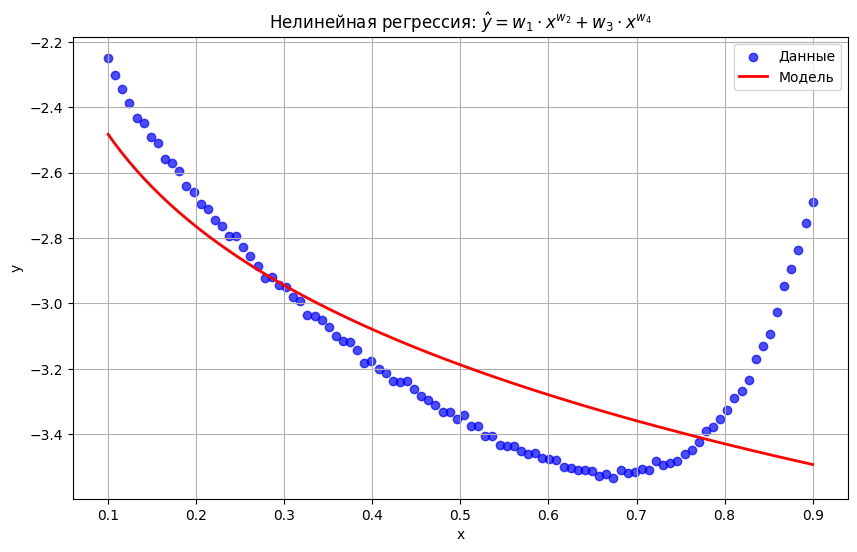

MSE на обучающей выборке: 0.044947


In [2]:
from scipy.optimize import curve_fit

x=[0.1,0.10808081,0.11616162,0.12424242,0.13232323,0.14040404,
   0.14848485,0.15656566,0.16464646,0.17272727,0.18080808,
   0.18888889,0.1969697,0.20505051,0.21313131,0.22121212,
   0.22929293,0.23737374,0.24545455,0.25353535,0.26161616,
   0.26969697,0.27777778,0.28585859,0.29393939,0.3020202,
   0.31010101,0.31818182,0.32626263,0.33434343,0.34242424,
   0.35050505,0.35858586,0.36666667,0.37474747,0.38282828,
   0.39090909,0.3989899,0.40707071,0.41515152,0.42323232,
   0.43131313,0.43939394,0.44747475,0.45555556,0.46363636,
   0.47171717,0.47979798,0.48787879,0.4959596,0.5040404,
   0.51212121,0.52020202,0.52828283,0.53636364,0.54444444,
   0.55252525,0.56060606,0.56868687,0.57676768,0.58484848,
   0.59292929,0.6010101,0.60909091,0.61717172,0.62525253,
   0.63333333,0.64141414,0.64949495,0.65757576,0.66565657,
   0.67373737,0.68181818,0.68989899,0.6979798,0.70606061,
   0.71414141,0.72222222,0.73030303,0.73838384,0.74646465,
   0.75454545,0.76262626,0.77070707,0.77878788,0.78686869,
   0.79494949,0.8030303,0.81111111,0.81919192,0.82727273,
   0.83535354,0.84343434,0.85151515,0.85959596,0.86767677,
   0.87575758,0.88383838,0.89191919,0.9]

y = [-2.24812911, -2.30215341, -2.34463875, -2.38651064,
     -2.43190693, -2.44713884, -2.49003176, -2.51006098, 
     -2.55831541, -2.57056931, -2.59340317, -2.64026441, 
     -2.65975636, -2.69517476, -2.71046599, -2.74422696, 
     -2.76251291, -2.79505506, -2.79301352, -2.82852207, 
     -2.854651, -2.88654236, -2.92345136, -2.91943321, 
     -2.94240833, -2.9487781, -2.97926813, -2.99198343, 
     -3.03396292, -3.03814694, -3.04944858, -3.07196161, 
     -3.09883706, -3.11338258, -3.11898122, -3.14254571, 
     -3.18330957, -3.17453301, -3.20021237, -3.21213539, 
     -3.23715191, -3.24017664, -3.23640684, -3.26147762, 
     -3.28208909, -3.29453546, -3.31160478, -3.33188752, 
     -3.33320305, -3.35238927, -3.34176317, -3.37471911, 
     -3.37543159, -3.40452694, -3.40505804, -3.43358858, 
     -3.43596139, -3.43705603, -3.45264647, -3.46029402, 
     -3.45723979, -3.4720453, -3.47597438, -3.4795529, 
     -3.50118552, -3.5031452, -3.5097196, -3.51083668, 
     -3.51128397, -3.52708836, -3.5222885, -3.53317295, 
     -3.50965143, -3.51939652, -3.51659198, -3.50734187, 
     -3.50882329, -3.48129755, -3.49384658, -3.48813707, 
     -3.48345018, -3.46180698, -3.44784696, -3.42372263, 
     -3.39080674, -3.37867045, -3.35281766, -3.32575498, 
     -3.28934964, -3.26814804, -3.23547615, -3.1707224, 
     -3.12910072, -3.09300443, -3.02523152, -2.9453774, 
     -2.89454317, -2.83662685, -2.75433056, -2.68946573]

x = np.array(x)
y = np.array(y)

def model(x, w1, w2, w3, w4):
    return w1 * (x ** w2) + w3 * (x ** w4)

x_norm = x / np.max(x)
y_norm = y / np.max(np.abs(y))

p0 = [1.0, 1.0, 1.0, 1.0]

popt, pcov = curve_fit(model, x_norm, y_norm, p0=p0, maxfev=100)
w1, w2, w3, w4 = popt
print(f"Оценки параметров: w1={w1:.6f}, w2={w2:.6f}, w3={w3:.6f}, w4={w4:.6f}")


y_pred = model(x_norm, w1, w2, w3, w4)
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Данные', color='blue', alpha=0.7)
plt.plot(x, y_pred * np.max(np.abs(y)), label='Модель', color='red', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Нелинейная регрессия: $\\hat{y} = w_1 \\cdot x^{w_2} + w_3 \\cdot x^{w_4}$')
plt.legend()
plt.grid(True)
plt.show()

mse = np.mean((y - y_pred * np.max(np.abs(y)))**2)
print(f"MSE на обучающей выборке: {mse:.6f}")

## 2

In [3]:
def dichotomy(f, a, b, eps=1e-6, max_iter=1000):
    iter_count = 0
    while (b - a) > eps and iter_count < max_iter:
        c = (a + b) / 2
        
        delta = eps / 2
        x1 = c - delta
        x2 = c + delta
        if f(x1) < f(x2):
            b = x2
        else:
            a = x1
        iter_count += 1
    return (a + b) / 2, iter_count


def golden_section(f, a, b, eps=1e-6, max_iter=1000):
    phi = (np.sqrt(5) - 1) / 2  # ~0.618
    iter_count = 0
    x1 = a + (1 - phi) * (b - a)
    x2 = a + phi * (b - a)
    f1 = f(x1)
    f2 = f(x2)
    while (b - a) > eps and iter_count < max_iter:
        if f1 < f2:
            b = x2
            x2 = x1
            f2 = f1
            x1 = a + (1 - phi) * (b - a)
            f1 = f(x1)
        else:
            a = x1
            x1 = x2
            f1 = f2
            x2 = a + phi * (b - a)
            f2 = f(x2)
        iter_count += 1
    return (a + b) / 2, iter_count

In [4]:
def f1(t):
    return t**4 / 4 - 2*t**2

def f2(t):
    return t * np.exp(-t**2 / 2)

a1, b1 = -3, 3  # для f1
a2, b2 = -2, 2  # для f2

min_dich1, iters_dich1 = dichotomy(f1, a1, b1)
min_gold1, iters_gold1 = golden_section(f1, a1, b1)

min_dich2, iters_dich2 = dichotomy(f2, a2, b2)
min_gold2, iters_gold2 = golden_section(f2, a2, b2)

print("=== Функция 1: f(t) = t^4/4 - 2t^2 ===")
print(f"Метод дихотомии: минимум в t={min_dich1:.6f}, итераций: {iters_dich1}")
print(f"Метод золотого сечения: минимум в t={min_gold1:.6f}, итераций: {iters_gold1}")

print("\n=== Функция 2: f(t) = t * exp(-t^2/2) ===")
print(f"Метод дихотомии: минимум в t={min_dich2:.6f}, итераций: {iters_dich2}")
print(f"Метод золотого сечения: минимум в t={min_gold2:.6f}, итераций: {iters_gold2}")

=== Функция 1: f(t) = t^4/4 - 2t^2 ===
Метод дихотомии: минимум в t=2.000000, итераций: 1000
Метод золотого сечения: минимум в t=2.000000, итераций: 33

=== Функция 2: f(t) = t * exp(-t^2/2) ===
Метод дихотомии: минимум в t=-1.000000, итераций: 1000
Метод золотого сечения: минимум в t=-1.000000, итераций: 32


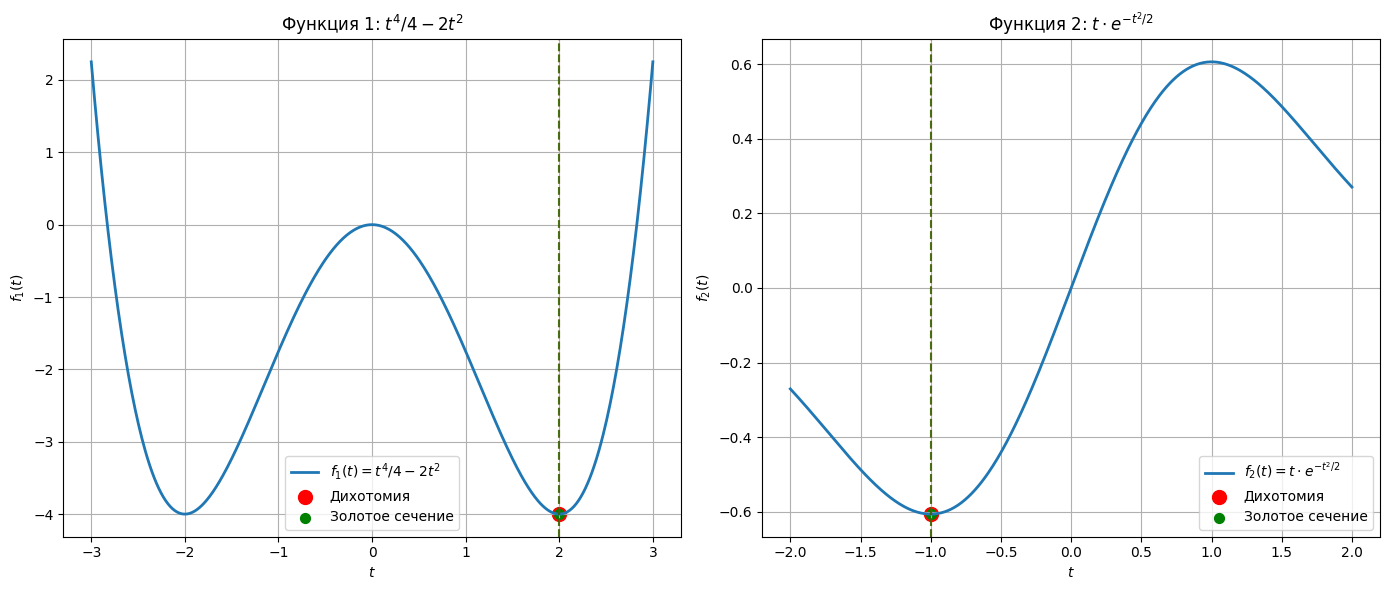

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# f1
t_vals1 = np.linspace(a1, b1, 500)
f_vals1 = f1(t_vals1)
axes[0].plot(t_vals1, f_vals1, label='$f_1(t) = t^4/4 - 2t^2$', linewidth=2)
axes[0].scatter([min_dich1], [f1(min_dich1)], color='red', s=100, label='Дихотомия')
axes[0].scatter([min_gold1], [f1(min_gold1)], color='green', s=50, label='Золотое сечение')
axes[0].axvline(x=min_dich1, color='red', linestyle='--', alpha=0.7)
axes[0].axvline(x=min_gold1, color='green', linestyle='--', alpha=0.7)
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$f_1(t)$')
axes[0].set_title('Функция 1: $t^4/4 - 2t^2$')
axes[0].legend()
axes[0].grid(True)

# f2
t_vals2 = np.linspace(a2, b2, 500)
f_vals2 = f2(t_vals2)
axes[1].plot(t_vals2, f_vals2, label='$f_2(t) = t \\cdot e^{-t^2/2}$', linewidth=2)
axes[1].scatter([min_dich2], [f2(min_dich2)], color='red', s=100, label='Дихотомия')
axes[1].scatter([min_gold2], [f2(min_gold2)], color='green', s=50, label='Золотое сечение')
axes[1].axvline(x=min_dich2, color='red', linestyle='--', alpha=0.7)
axes[1].axvline(x=min_gold2, color='green', linestyle='--', alpha=0.7)
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$f_2(t)$')
axes[1].set_title('Функция 2: $t \\cdot e^{-t^2/2}$')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3

/tmp/ipykernel_251195/1947624583.py:6: RuntimeWarning: overflow encountered in scalar power
  return 20 + x1**2 + x2**2 - 10*np.cos(2*np.pi*x1) - 10*np.cos(2*np.pi*x2)
/home/tim/myenv/lib64/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


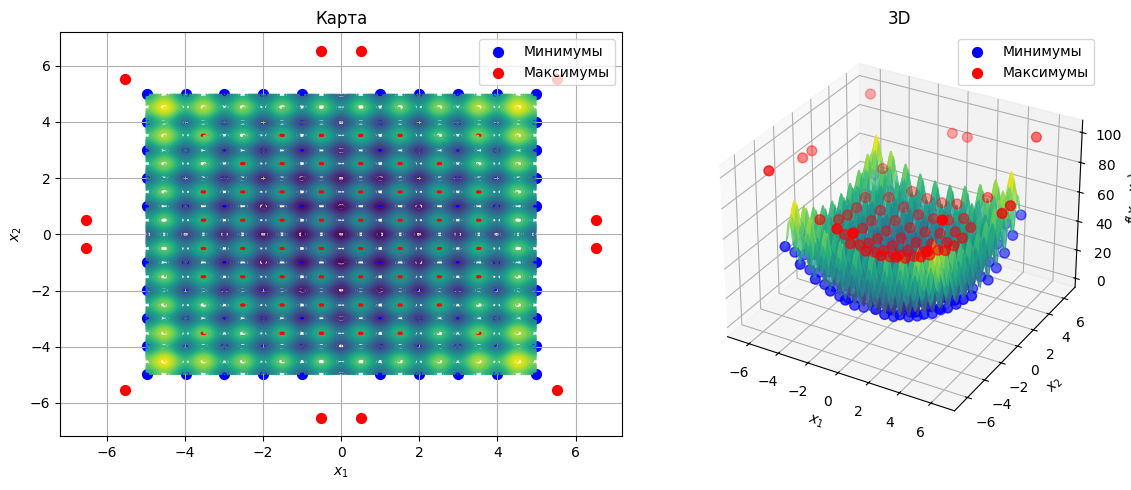

Найдено локальных минимумов: 92
Найдено локальных максимумов: 68


In [6]:
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

def rastrigin(x):
    x1, x2 = x
    return 20 + x1**2 + x2**2 - 10*np.cos(2*np.pi*x1) - 10*np.cos(2*np.pi*x2)

mins = []
maxs = []

grid = np.linspace(-5, 5, 10)
for x1 in grid:
    for x2 in grid:
        # Min
        res_min = minimize(rastrigin, [x1, x2], method='L-BFGS-B')
        if res_min.success:
            mins.append(res_min.x)
        # Max (-Min)
        res_max = minimize(lambda x: -rastrigin(x), [x1, x2], method='L-BFGS-B')
        if res_max.success:
            maxs.append(res_max.x)

mins = np.unique(np.round(mins, decimals=3), axis=0)
maxs = np.unique(np.round(maxs, decimals=3), axis=0)

# 2D
x1_grid, x2_grid = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
z_grid = rastrigin([x1_grid, x2_grid])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contour(x1_grid, x2_grid, z_grid, levels=50, cmap='viridis')
plt.scatter(mins[:, 0], mins[:, 1], c='blue', s=50, label='Минимумы')
plt.scatter(maxs[:, 0], maxs[:, 1], c='red', s=50, label='Максимумы')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Карта')
plt.legend()
plt.grid(True)

# 3D
ax = plt.subplot(1, 2, 2, projection='3d')
ax.plot_surface(x1_grid, x2_grid, z_grid, cmap='viridis', alpha=0.8)
ax.scatter(mins[:, 0], mins[:, 1], [rastrigin(p) for p in mins], c='blue', s=50, label='Минимумы')
ax.scatter(maxs[:, 0], maxs[:, 1], [rastrigin(p) for p in maxs], c='red', s=50, label='Максимумы')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x_1,x_2)$')
ax.set_title('3D')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Найдено локальных минимумов: {len(mins)}")
print(f"Найдено локальных максимумов: {len(maxs)}")

## 4

Графику с зигзагообразной функцией соответсвует метод наискорейшего спуска, т.е. на каждом шаге направление поиска выбирается строго вдоль антиградиента, то есть перпендикулярно линии уровня (следовательно замкнутые линии есть линии уровня целевой функции). Более прямая траектория соответствует CG, т.к. он учитывает старое направление, выбирая новое по кривизне поверхности (для удаленных линий уровня такие направления будут близки друг в другу).

### *Докажем теперь, что метод сопряженных градиентов сходится не более чем за n шагов

Рассмотрим квадратичную функцию:
$$
f(x) = \frac{1}{2} x^T A x - b^T x,
$$
где $A \in \mathbb{R}^{n \times n}$ — симметричная положительно определенная матрица.

На $k$-й итерации метод строит направление $d_k$, $A$-сопряженное ко всем предыдущим направлениям: $d_i^T A d_j = 0$ при $i \ne j$. После $k$ шагов текущая точка $x_k$ лежит в подпространстве $\text{span}\{d_0, \dots, d_{k-1}\}$. Поскольку в $\mathbb{R}^n$ можно построить не более $n$ линейно независимых $A$-сопряженных векторов, то за $n$ шагов метод достигает глобального минимума, ч.т.д.

## 5

На овражных функциях линии уровня сильно вытянуты. Градиент указывает в направлении наибольшего роста, перпендикулярном линиям уровня. В овраге это направление почти перпендикулярно дну $\implies$ метод совершает зигзагообразные движения по склонам, а не напрямую к минимуму $\implies$ сходится медленее

---
Как связан овражный характер функции с величиной наименьшего сингулярного числа матрицы квадратичной формы? А с величиной числа обусловленности матрицы?

Линии уровня функции $f(x)$ — это эллипсоиды, заданные уравнением:
$$
x^T A x = \text{const}.
$$

После диагонализации $A = Q \Lambda Q^T$, где $\Lambda = \text{diag}(\lambda_1, \dots, \lambda_n)$, $\lambda_i > 0$ — собственные значения, а $Q$ — ортогональная матрица. Перейдем к новым координатам $y = Q^T x$. В этих координатах уравнение линий уровня принимает вид:
$$
\sum_{i=1}^n \lambda_i y_i^2 = \text{const},
$$
что является уравнением эллипсоида с полуосями, пропорциональными $1/\sqrt{\lambda_i}$.

Следовательно, чем больше разброс собственных значений $\lambda_i$, тем сильнее вытянут эллипсоид, причем максимальное "вытягивание" происходит в направлении, соответствующем наименьшему собственному значению $\lambda_{\min}$ (полуось $1/\sqrt{\lambda_{\min}}$ — самая длинная) и аналогично минимальное - в направлении наибольшего собственного значения.

Вспомним, что число обусловленности матрицы $A$ есть $\kappa(A) = \frac{\lambda_{\max}}{\lambda_{\min}}$.

Тогда можно переформулировать утверждение выше в виде:
- Чем больше $\kappa(A)$, тем сильнее вытянуты линии уровня (т.е. функция овражная)
- При $\kappa(A) \approx 1$ линии уровня близки к сферам
- При $\kappa(A) \gg 1$ линии уровня сильно вытянуты

Для симметричной положительно определенной матрицы $A$ её сингулярные числа совпадают с абсолютными значениями собственных значений, то есть:
$$
\sigma_i = |\lambda_i| = \lambda_i > 0.
$$

Следовательно:
- Наименьшее сингулярное число: $\sigma_{\min} = \lambda_{\min}$.
- Наибольшее сингулярное число: $\sigma_{\max} = \lambda_{\max}$.
- Число обусловленности: $\kappa(A) = \sigma_{\max} / \sigma_{\min}$.

Тогда при фиксированном $\sigma_{\max}$ чем меньше $\sigma_{\min}$ тем более овражной является целевая функция

---

Посмотрев на рисунок можно сделать вывод, что покоординатный спуск также страдает от овражного характера целевой функции. Он движется только вдоль осей координат, которые могут быть не согласованы с направлением дна оврага.